**Data Source**
Updated Document Link

The Dataset was fetched from Kaggle, accessible [here](https://www.kaggle.com/datasets/niraliivaghani/flipkart-product-customer-reviews-dataset).

This dataset contains information about Product name, Product price, Rate, Reviews, Summary and Sentiment in csv format of `Flipkart's` E-Commerce Products. It will be used to carry out Sentiment Analysis.

**Note**

BERT pretrained Model finetuning was implemented in another Collab File due to RAM Limitations. You can find it here : [Bert Collab](https://colab.research.google.com/drive/1yAijwJORm9yeWv2HX7GYlZNpcbpNq-al?usp=sharing)

To do the training, I used `bert-base-uncased` pretrained model as it had fewer parameters(109 M)  compared to the other bert pretrained models such as `bert-base-multilingual-uncased-sentiment`.

**Importing Libraries**

I imported the necessary Python libraries. pandas is used for data manipulation and analysis, and numpy is used for numerical operations. This is important for handling the dataset and performing calculations.

In [ ]:
import pandas as pd
import numpy as np

df_reviews = pd.read_csv("/content/drive/MyDrive/Data Mining/flipkart_product_reviews.csv")

df_reviews.rename(columns={'Review': 'Summary', 'Summary': 'Customer Review'}, inplace=True)


**Displaying data**

Then I loaded the dataset into a pandas DataFrame. It contains information on product_name as well as product_price, Rate, Summary, Customer Review and Sentiment.

**product_name**: The name of the product being reviewed.

**product_price**: The price of the product.

**Rate**: The rating given by the customer (on a scale, 1-5).

**Review**: A short review headline provided by the customer.

**Summary**: A more detailed summary of the customer's experience.

**Sentiment**: The sentiment of the review categorized as positive, neutral, or negative.


In [ ]:
df_reviews.head()

,product_name,product_price,Rate,Summary,Customer Review,Sentiment
0,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999,5,super!,great cooler excellent air flow and for this p...,positive
1,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999,5,awesome,best budget 2 fit cooler nice cooling,positive
2,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999,3,fair,the quality is good but the power of air is de...,positive
3,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999,1,useless product,very bad product its a only a fan,negative
4,Candes 12 L Room/Personal Air Cooler??????(Whi...,3999,3,fair,ok ok product,neutral


### Data Preprocessing

I used the df_reviews.info() command to display the information about the DataFrame named df_reviews, which contains data related to product reviews. This DataFrame consists of 205,052 entries, indicating the number of product reviews captured. There are six columns in the dataset, all of which are of the object (string) data type.

In [ ]:
df_reviews.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205052 entries, 0 to 205051
Data columns (total 6 columns):
 #   Column           Non-Null Count   Dtype 
---  ------           --------------   ----- 
 0   product_name     205052 non-null  object
 1   product_price    205052 non-null  object
 2   Rate             205052 non-null  object
 3   Summary          180388 non-null  object
 4   Customer Review  205041 non-null  object
 5   Sentiment        205052 non-null  object
dtypes: object(6)
memory usage: 9.4+ MB


**Null Values**

Null values were dropped from the dataset. Attempting to impute these missing values would potentially distort the associated sentiment or ratings. For instance, inaccurately imputing the "Summary" field with available techniques—which do not assure perfect alignment—might have led to instances where a negative review was mistakenly paired with a positive sentiment or a high rating. Given the ample size of the dataset, dropping the null values emerged as the most prudent strategy to circumvent such discrepancies.

*product_name:* No missing values

*product_price:* Also has no missing values, with all reviews including the product price.

*Rate*: No missing values, ensuring that every review includes a rating.

*Summary:* Contains 24,664 missing values, highlighting that not all reviews include a summary. This could affect analyses since it relies on textual summaries and will be addressed

*Customer Review:* 11 missing values Given the dataset's size, this represents a minimal proportion of the total data.

*Sentiment*: No missing values

In [ ]:
df_reviews.isnull().sum()

product_name           0
product_price          0
Rate                   0
Summary            24664
Customer Review       11
Sentiment              0
dtype: int64

I used the .dropna() method to remove any rows with missing values to ensure the model trains on complete data. The sentiment labels are then converted from strings ('Positive' and 'Negative') to binary integers (1 and 0), making them suitable for a binary classification task.

In [ ]:
df_reviews.dropna(inplace=True, axis=0)


I executed `df_reviews['Sentiment'].unique()`. in order to identify the unique values within the 'Sentiment' column of the ` df_reviews DataFrame` . The result indicates that there are three unique sentiment values assigned to the product reviews:

*Positive*: Signifies reviews that have been assessed or analyzed to reflect a favorable view or satisfaction with the product.

*Negative*: Indicates reviews that express dissatisfaction or unfavorable opinions about the product.

*Neutral*: Represents reviews that neither express clear satisfaction nor dissatisfaction, or could be considered as providing objective comments without a strong emotional tone.

In [ ]:
df_reviews['Sentiment'].unique()

array(['positive', 'negative', 'neutral'], dtype=object)

In [ ]:
!pip install plotly

To gain an overview of the quantity and understand the distribution of the sentiments, I would be visualizing the data

Positive sentiment is represented by green,

Negative sentiment by red, and

Neutral sentiment by blue


In [ ]:
import plotly.graph_objects as go
# This line counts the occurrences of each unique sentiment value within the 'Sentiment' column of the DataFrame,
# which is crucial for understanding the frequency of each sentiment type in the dataset.
sentiment_counts = df_reviews['Sentiment'].value_counts()

colors = ['green', 'red', 'blue']

fig = go.Figure()

for i, sentiment in enumerate(sentiment_counts.index):
    fig.add_trace(go.Bar(x=[sentiment], y=[sentiment_counts[sentiment]], name=sentiment, marker_color=colors[i]))

fig.update_traces(marker_line_width=0.5, width=0.3)

fig.update_layout(
    title='Sentiment Distribution',
    xaxis_title='Sentiment',
    yaxis_title='Count',
    showlegend=True,
    bargap=0.1,
    title_x=0.5
)

fig.show()


**Findings:**
The above chart indicates that the largest number dominating the green bar are a lot. This means that there are many positive reviews given by customers. Which is a good sign for any business since it shows that most of the customers have experiences with their products that are favorable.

The red bar is much less than the green one; it represents negative reviews. It's nice to know that the pool of unhappy customers is smaller, but that part cant be disregarded. All those negative reviews can be converted into feedbacks that pinpoint sources of insight for either product flaws or customer pain points which, when resolved, might  improve overall quality or customer satisfaction.

The blue bar signifies neutral reviews, which are fewer than positive but slightly more than negative. These may come from customers who are relatively not satisfied or even not that dissatisfied by the products or may contain some reasonable feedback without a strong emotional tone.

In [ ]:
#
def clean_data(df, column_name):
    df[column_name] = df[column_name].str.replace(r'\?\?\?\?\?\?', '')
    return df

df_reviews = clean_data(df_reviews, 'product_name')

<ipython-input-9-d2bf920555ba>:3: FutureWarning:

The default value of regex will change from True to False in a future version.



In [ ]:
# To offer a richer data for the model, I used 'Customer Reviews' Column instead of a Summary of those Reviews.
import re

def clean_text(text):
    text = re.sub(r'[^a-zA-Z\s]', '', text, re.I|re.A)
    text = text.lower()
    return text

df_reviews['Customer Review'] = df_reviews['Customer Review'].apply(clean_text)

In [ ]:
# Create a separate df for BERT  Pretrained model
df_bert = df_reviews.copy(deep=True)

**Remove Stop Words, and Lemmatize**

In [ ]:
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
import nltk



# Remove stopwords, tokenize, Lemmatization
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')

# Loading the list of English stopwords. These are words like 'the', 'is', etc.,
stop_words = set(stopwords.words('english'))

# Initializing the WordNet Lemmatizer, which is used to reduce words to their base
lemmatizer = WordNetLemmatizer()

# Applying preprocessing steps to the 'Customer Review' column of the df_reviews DataFrame.
df_reviews['Customer Review'] = df_reviews['Customer Review'].apply(lambda x: ' '.join([lemmatizer.lemmatize(word) for word in word_tokenize(x.lower())
                                  if word.isalpha() and word not in stop_words]))




[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


In [ ]:
# Lemmatized Customer Review
df_reviews.head()

,product_name,product_price,Rate,Summary,Customer Review,Sentiment
0,"Candes 12 L Room/Personal Air Cooler(White, Bl...",3999,5,super!,great cooler excellent air flow price amazing ...,positive
1,"Candes 12 L Room/Personal Air Cooler(White, Bl...",3999,5,awesome,best budget fit cooler nice cooling,positive
2,"Candes 12 L Room/Personal Air Cooler(White, Bl...",3999,3,fair,quality good power air decent,positive
3,"Candes 12 L Room/Personal Air Cooler(White, Bl...",3999,1,useless product,bad product fan,negative
4,"Candes 12 L Room/Personal Air Cooler(White, Bl...",3999,3,fair,ok ok product,neutral


In [ ]:
from wordcloud import WordCloud
import plotly.graph_objects as go

def generate_wordcloud(df_reviews, sentiment):
   # Filter reviews by the specified sentiment.
    sentiment_reviews = df_reviews[df_reviews['Sentiment'] == sentiment]
    # Combined all reviews of the specified sentiment into one large string.
    sentiment_reviews_text = ' '.join(sentiment_reviews['Customer Review'])

    # Generate word cloud
    # I set the word cloud's dimensions to 800x400 pixels, with a white background
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(sentiment_reviews_text)

    # Converting the word cloud image to an array and create a Plotly figure using that array.
    # 'hoverinfo='skip'' disables hover information for the image.
    wordcloud_plotly = go.Figure(go.Image(z=wordcloud.to_array(), hoverinfo='skip'))

    wordcloud_plotly.update_layout(title=f'Word Cloud for {sentiment.capitalize()} Sentiment', title_x=0.5)
    wordcloud_plotly.update_xaxes(visible=False)
    wordcloud_plotly.update_yaxes(visible=False)

    wordcloud_plotly.show()


generate_wordcloud(df_reviews, 'positive')


In [ ]:
generate_wordcloud(df_reviews, 'negative')

In [ ]:
generate_wordcloud(df_reviews, 'neutral')


**Findings:** From the 3 Word clouds, majority of Customers used the similar words to describe Positive or Neutral Reviews. If the majority of customers are using similar words to describe positive or neutral reviews across multiple word clouds, it suggests several important points:

1. Consistency in Customer Experience -  Consistent use of certain words across positive or neutral reviews may indicate that customers are experiencing similar aspects of the product or service. This consistency can be seen as a reflection of the reliability and consistency of the customer experience provided by the business.

2. Customer Expectations -  Consistent language in reviews may also reflect customers' expectations and priorities. Businesses can use this information to align their offerings with customer expectations, ensuring that they deliver products or services that meet or exceed customer needs and preferences.

3. Brand Perception  

4. Opportunities for Improvement -  While consistency in positive or neutral reviews is generally positive, it also provides opportunities for businesses to identify areas for improvement. Analyzing common words or phrases in these reviews can help businesses pinpoint areas where they can enhance their offerings or address customer concerns to further improve customer satisfaction and loyalty.


**Sentiment By Product**

This aggregates sentiment data for each product, showing the distribution of sentiments expresses in reviews for each product in a table.

Business can compare sentiment distributions across products helping them priotize areas of improvement.

As seen below cello Pack of 18 Opalware Cello Dazzle Lush Fiesta Opalware Dinner Set, 18 Pieces Dinner SetÃÂ ÃÂ (White, Microwave Safe) has the highest amount of positive sentiment which means it is likely meeting or exceeding customer expectations.

In [ ]:
# Group by 'product_name' and aggregate sentiment counts
sentiment_counts = df_reviews.groupby('product_name')['Sentiment'].value_counts().unstack(fill_value=0)

unique_products = df_reviews.drop_duplicates(subset='product_name', keep='first')['product_name']

# Filter the sentiment counts for unique products
unique_sentiment_counts = sentiment_counts.loc[unique_products]

unique_sentiment_counts

Sentiment,negative,neutral,positive
product_name,,,
"Candes 12 L Room/Personal Air Cooler(White, Black, Elegant High Speed-Honey Comb Cooling Pad & Ice Chamber, Blower)",2,1,7
"Candes 60 L Room/Personal Air Cooler(White, Black, CRETA)",1,0,25
"MAHARAJA WHITELINE 65 L Desert Air Cooler(White, Grey, Rambo Grey / AC-303)",95,34,651
"Crompton 75 L Desert Air Cooler(White, Teal, ACGC-DAC751)",188,40,955
"boAt Rockerz 510 Super Extra Bass Bluetooth Headset(Molten Orange, On the Ear)",28,8,864
...,...,...,...
BeeSmart Semi Automatic Water Level Controller Manual on Auto Off 30 A Relay Model BEEWLC2 Wired Sensor Security System,0,0,11
SMBT Anti Theft System Security Pad Lock with Burglar Smart Alarm Siren Motion Sensor Secure for Home Door gate Cycle Shop Bike Office Shutter Safety Lock Safety LockBlack,1,1,16
cello Pack of 18 Opalware Cello Dazzle Tropical Lagoon Opalware Dinner Set 18 Pieces Dinner SetWhite Microwave Safe,12,0,108


The Product/Sentiment data provides an indication of how customers perceive each product. Products with a higher number of positive sentiments are likely to be well-received by customers, while products with a higher number of negative sentiments may have shortcomings that need to be addressed. These shortcomings can be generated from the Customer Reviews Provided. Other areas this can be used include Comparison Across Products, Product Operational Insights such as product quality, customer service effectiveness, and marketing effectiveness.

**Findings**: Product Sentiment Variation: There is a notable variation in sentiment across different products. For instance, the Candes 12 L Air Cooler received a modest number of reviews with the majority being positive (7 positive, 2 negative, and 1 neutral). In contrast, the cello Pack of 18 Opalware Dinner Set has a significantly higher volume of reviews, with an overwhelming number of positive sentiments (5267 positive) compared to negative (602 negative) and neutral (136 neutral).

*High Volume Products*: Products like the MAHARAJA WHITELINE 65 L Desert Air Cooler and the Crompton 75 L Desert Air Cooler show a large number of positive reviews (651 and 955, respectively), with a smaller proportion of negative reviews. This suggests that customers are largely satisfied with these products, though the number of negative reviews could point to specific areas for improvement.

*Discrepancy in Sentiment Proportions:* Some products have a very high discrepancy between the number of positive and negative sentiments. For example, the boAt Rockerz 510 Bluetooth Headset has received significantly more positive reviews (864) compared to negative ones (28). Such disparities could be indicative of the overall market reception of the product and could influence stock and marketing strategies.

*Overall Sentiment Leanings*: Across the 841 products analyzed, the sentiment leans heavily toward positive. This indicates a general customer satisfaction with the products listed. However, the presence of negative reviews, even in smaller numbers, should not be overlooked as they can provide critical insights into customer dissatisfaction and potential quality issues.


**Encode Sentiments**

 Performing label encoding to convert categorical sentiment labels into numerical representations

In [ ]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

# Encoding the 'Sentiment' column of the DataFrame 'df_reviews' and storing the encoded values in a new column 'Sentiment_encoded'
df_reviews['Sentiment_encoded'] = label_encoder.fit_transform(df_reviews['Sentiment'])

# Printing the mapping between original sentiment labels and their corresponding encoded labels
print("Mapping between original sentiment and encoded labels :\n")
for label, encoded_label in zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)):
    print(f"{label}: {encoded_label}")

Mapping between original sentiment and encoded labels :

negative: 0
neutral: 1
positive: 2


**Vectorize**

Converted the text data from the 'Customer Review' column of the DataFrame df_reviews into a TF-IDF representation using the TfidfVectorizer, and then retrieve the dimensions of the resulting TF-IDF matrix

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
vectorizer = TfidfVectorizer()
reviews_corpus = vectorizer.fit_transform(df_reviews['Customer Review'])

reviews_corpus.shape

(180379, 39442)

In [ ]:
reviews_corpus

<180379x39442 sparse matrix of type '<class 'numpy.float64'>'
	with 856007 stored elements in Compressed Sparse Row format>

**Model Training**

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(reviews_corpus, df_reviews['Sentiment_encoded'], test_size=0.3, random_state=42)

**Dimensionality Reduction**

Dimensionality Reduction was applied to cut on the time and resources taken to train the model. Dimensions were reduced from 39442 to 20. We used TruncatedSVD as it supports Sparse Matrix Input, unlike PCA which does not.

In [ ]:
from sklearn.decomposition import TruncatedSVD

svd = TruncatedSVD(n_components=20)

# Transform the sparse input matrices
X_train = svd.fit_transform(X_train)
X_test = svd.transform(X_test)


**SVM Algorithm**

In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score


svm_classifier = SVC(kernel='linear')

svm_classifier.fit(X_train, y_train)


SVC(kernel='linear')

**Logistic Regression**


In [ ]:
from sklearn.linear_model import LogisticRegression

log_classifier = LogisticRegression(max_iter=1000, multi_class='multinomial', solver='lbfgs')


log_classifier.fit(X_train, y_train)


LogisticRegression(max_iter=1000, multi_class='multinomial')

**Model Prediction**

Accuracy score for SVM: 84.61%

In [ ]:
# Load Model
import joblib
from sklearn.metrics import classification_report, accuracy_score



# Predictions on the testing set
y_pred = svm_classifier.predict(X_test)

# Evaluate the model
print(f" SVM Accuracy Score :  {accuracy_score(y_test, y_pred)}\n")


0.8461026721366005


In [ ]:
y_pred_lr =  log_classifier.predict(X_test)
print(f" Logistic Regression Accuracy Score :  {accuracy_score(y_test, y_pred_lr)}")


 Logistic Regression Accuracy Score :  0.8609601951435858


In [ ]:
print(" SVM Classification Report\n")
print(classification_report(y_test, y_pred,  target_names=['negative', 'neutral', 'positive']))

              precision    recall  f1-score   support

    negative       0.73      0.24      0.37      7364
     neutral       0.74      0.23      0.35      2625
    positive       0.85      0.98      0.91     44125

    accuracy                           0.85     54114
   macro avg       0.77      0.48      0.54     54114
weighted avg       0.83      0.85      0.81     54114



In [ ]:
print(" Logistic Regression Classification Report\n")
print(classification_report(y_test, y_pred_lr,  target_names=['negative', 'neutral', 'positive']))

 Logistic Regression Classification Report

              precision    recall  f1-score   support

    negative       0.78      0.34      0.48      7364
     neutral       0.80      0.23      0.36      2625
    positive       0.87      0.98      0.92     44125

    accuracy                           0.86     54114
   macro avg       0.82      0.52      0.59     54114
weighted avg       0.85      0.86      0.83     54114



In [ ]:
import joblib

file_name = '/content/drive/MyDrive/Data Mining/svc_model.joblib'
file_name2 = '/content/drive/MyDrive/Data Mining/lr_model.joblib'


joblib.dump(svm_classifier, file_name)
joblib.dump(log_classifier, file_name2)


print(f"SVC(SVM) model saved at: {file_name}")
print(f"logistic Regression model saved at: {file_name2}")

SVC(SVM) model saved at: /content/drive/MyDrive/Data Mining/svc_model.joblib
logistic Regression model saved at: /content/drive/MyDrive/Data Mining/lr_model.joblib


**SVC Algorithm Optimization**

Gridsearch method was used for hyperparameter optimization due to its systematic and efficient exploration of hyperparameter combinations. It employs cross-validation during the search, providing a robust evaluation of model performance across multiple subsets of the training data.

The final model obtained from GridSearch was trained using the best hyperparameter values.

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC
import numpy as np


svm_classifier_optimized = SVC()

# Hyperparameter grid to test

param_grid = {
    'C': [0.01,0.1],
    'gamma': [0.1, 0.01],
    'kernel': ['rbf']
}

# Reduced folds to 2 to reduce model complexity given the available resources
grid_search = GridSearchCV(svm_classifier_optimized, param_grid, cv=2)

grid_search.fit(X_train, y_train)


best_parameters = grid_search.best_params_
svm_optimized = grid_search.best_estimator_


y_pred_opt = svm_optimized.predict(X_test)

# Accuracy Score
accuracy_svm = accuracy_score(y_test, y_pred_opt)

print(f'Optimized SVM Classifier Accuracy: {accuracy_svm}')
print(f'SVM Best hyperparameters: {grid_search.best_params_}')

Fitting 2 folds for each of 1 candidates, totalling 2 fits
[CV] END .........................C=0.1, gamma=1, kernel=rbf; total time= 3.9min
[CV] END .........................C=0.1, gamma=1, kernel=rbf; total time= 3.3min
Optimized SVM Classifier Accuracy: 0.8688139852903131
SVM Best hyperparameters: {'C': 0.1, 'gamma': 1, 'kernel': 'rbf'}


**Logistic Regression Algorithm Optimization**

In [ ]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(max_iter=1000, multi_class='multinomial', solver='lbfgs')

param_grid = {

    'C': [0.1, 0.2],
    'solver': ['lbfgs', 'newton-cg'],
}

grid_search = GridSearchCV(log_reg, param_grid, cv=4)

grid_search.fit(X_train, y_train)


best_parameters = grid_search.best_params_
log_optimized = grid_search.best_estimator_


y_pred_log_opt = log_optimized.predict(X_test)

# Accuracy Score
accuracy_log_reg = accuracy_score(y_test, y_pred_log_opt)

print(f'Optimized Logistic Regression Accuracy: {accuracy_log_reg}')
print(f'Logistic Regression Best hyperparameters: {grid_search.best_params_}')

Optimized Logistic Regression Accuracy: 0.8566914292050116
Logistic Regression Best hyperparameters: {'C': 0.2, 'solver': 'newton-cg'}


In [ ]:
file_name3 = '/content/drive/MyDrive/Data Mining/svcoptimized_model.joblib'
file_name4 = '/content/drive/MyDrive/Data Mining/logoptimized_model.joblib'


joblib.dump(svm_optimized, file_name3)
joblib.dump(log_optimized, file_name4)



['/content/drive/MyDrive/Data Mining/logoptimized_model.joblib']

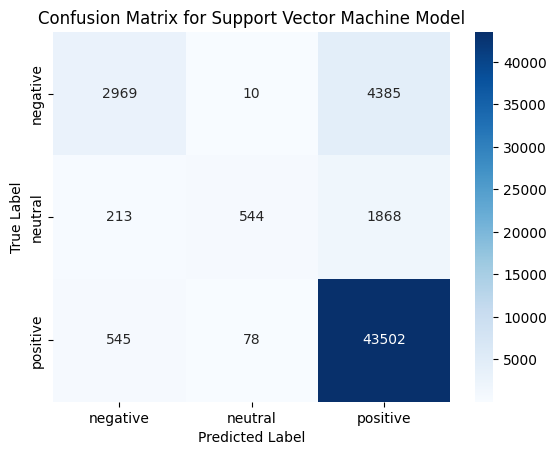

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm_svm = confusion_matrix(y_test, y_pred_opt)
class_names = ['negative', 'neutral', 'positive']

# Plot heatmap of confusion matrix
sns.heatmap(cm_svm, annot=True, cmap="Blues", fmt="d", xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix for Support Vector Machine Model")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()



The model seems to perform best when identifying positive sentiments, with a high number of true positives. The number of true negatives is also fairly high, but the true neutrals are relatively low.The false positives for positive sentiment are quite high, which means the model tends to predict positive sentiment more often than it should. This might indicate a bias towards predicting positive sentiment or an imbalance in the dataset where positive instances are more common, which is the case in the original dataset.


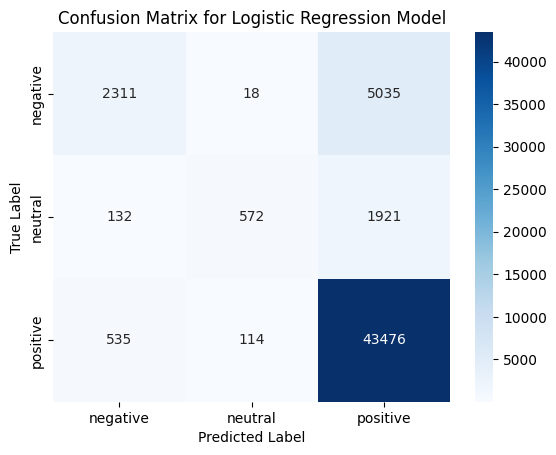

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm_svm = confusion_matrix(y_test, y_pred_log_opt)
class_names = ['negative', 'neutral', 'positive']

# Plot heatmap of confusion matrix
sns.heatmap(cm_svm, annot=True, cmap="Blues", fmt="d", xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix for Logistic Regression Model")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

**Test Model**

In [ ]:
def preprocess_text(text):
    # Tokenize, remove stop words, and lemmatize
    tokens = word_tokenize(text.lower())
    lemmatized_tokens = [lemmatizer.lemmatize(word) for word in tokens if word.isalpha() and word not in stop_words]
    return ' '.join(lemmatized_tokens)


revs = [
    "This product was great",
    "I'm not happy with this product",
    "It's okay, but I've seen better",
    "Absolutely fantastic! Would buy again.",
    "Terrible, it broke after one use.",
    "Just average, nothing special.",
    "Exceeded my expectations in every way.",
    "I regret purchasing this item.",
    "Meh, I was indifferent to this product.",
    "A stellar experience from start to finish.",
    "The worst customer service I've ever received.",
    "It does the job, but that's about it.",
    "Brilliant design and easy to use.",
    "This was a complete waste of money.",
    "Unremarkable product, I have no strong feelings.",
    "I'm thoroughly impressed with the quality.",
    "Not what was advertised, very disappointed.",
    "It's fine, I guess, but leaves a lot to be desired.",
    "An excellent choice for anyone looking for quality!",
    "Horrible, didn't work as expected at all.",  ]

revs_examples = [preprocess_text(text) for text in revs]


revs_matrix = vectorizer.fit_transform(revs_examples)
print(f"revs_matrix shape : ", revs_matrix.shape)
revs_reduced = svd.fit_transform(revs_matrix)

predictions_svm = svm_classifier.predict(revs_reduced)



# Output predictions
for text, pred_svm in zip(revs, predictions_svm):
    print(f"Text: {text}\nPreprocessed Text: {preprocess_text(text)}")
    print(f"Predicted sentiment with SVM: {pred_svm}\n")


revs_matrix shape :  (20, 62)
Text: This product was great
Preprocessed Text: product great
Predicted sentiment with SVM: 2

Text: I'm not happy with this product
Preprocessed Text: happy product
Predicted sentiment with SVM: 2

Text: It's okay, but I've seen better
Preprocessed Text: okay seen better
Predicted sentiment with SVM: 0

Text: Absolutely fantastic! Would buy again.
Preprocessed Text: absolutely fantastic would buy
Predicted sentiment with SVM: 2

Text: Terrible, it broke after one use.
Preprocessed Text: terrible broke one use
Predicted sentiment with SVM: 2

Text: Just average, nothing special.
Preprocessed Text: average nothing special
Predicted sentiment with SVM: 2

Text: Exceeded my expectations in every way.
Preprocessed Text: exceeded expectation every way
Predicted sentiment with SVM: 2

Text: I regret purchasing this item.
Preprocessed Text: regret purchasing item
Predicted sentiment with SVM: 2

Text: Meh, I was indifferent to this product.
Preprocessed Text: meh

In [ ]:
# Note : In this cell, I was experimenting on whether lemmatizing was better than stemming,

from nltk.stem import PorterStemmer
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

# Initialize the stemmer and stop words
stemmer = PorterStemmer()
def preprocess_text(text):
    # Tokenize, remove stop words, and stem
    tokens = word_tokenize(text.lower())
    stemmed_tokens = [stemmer.stem(word) for word in tokens if word.isalpha() and word not in stop_words]
    return ' '.join(stemmed_tokens)

revs = [
    "This product was great",
    "I'm not happy with this product",
    "It's okay, but I've seen better",
    "Absolutely fantastic! Would buy again.",
    "Terrible, it broke after one use.",
    "Just average, nothing special.",
    "Exceeded my expectations in every way.",
    "I regret purchasing this item.",
    "Meh, I was indifferent to this product.",
    "A stellar experience from start to finish.",
    "The worst customer service I've ever received.",
    "It does the job, but that's about it.",
    "Brilliant design and easy to use.",
    "This was a complete waste of money.",
    "Unremarkable product, I have no strong feelings.",
    "I'm thoroughly impressed with the quality.",
    "Not what was advertised, very disappointed.",
    "It's fine, I guess, but leaves a lot to be desired.",
    "An excellent choice for anyone looking for quality!",
    "Horrible, didn't work as expected at all.",  ]

revs_examples = [preprocess_text(text) for text in revs]


revs_matrix = vectorizer.fit_transform(revs_examples)
print(f"revs_matrix shape : ", revs_matrix.shape)
revs_reduced = svd.fit_transform(revs_matrix)

predictions_svm = svm_classifier.predict(revs_reduced)



# Output predictions
for text, pred_svm in zip(revs, predictions_svm):
    print(f"Text: {text}\nPreprocessed Text: {preprocess_text(text)}")
    print(f"Predicted sentiment with SVM: {pred_svm}\n")

revs_matrix shape :  (20, 61)
Text: This product was great
Preprocessed Text: product great
Predicted sentiment with SVM: 2

Text: I'm not happy with this product
Preprocessed Text: happi product
Predicted sentiment with SVM: 2

Text: It's okay, but I've seen better
Preprocessed Text: okay seen better
Predicted sentiment with SVM: 2

Text: Absolutely fantastic! Would buy again.
Preprocessed Text: absolut fantast would buy
Predicted sentiment with SVM: 2

Text: Terrible, it broke after one use.
Preprocessed Text: terribl broke one use
Predicted sentiment with SVM: 2

Text: Just average, nothing special.
Preprocessed Text: averag noth special
Predicted sentiment with SVM: 2

Text: Exceeded my expectations in every way.
Preprocessed Text: exceed expect everi way
Predicted sentiment with SVM: 2

Text: I regret purchasing this item.
Preprocessed Text: regret purchas item
Predicted sentiment with SVM: 1

Text: Meh, I was indifferent to this product.
Preprocessed Text: meh indiffer product
Pr

##Conclusion

This analysis outlines the potential behind analyzing positive and neutral reviews, in order to leverage customer feedback for SMEs in Africa.

The model can be developed into a recommendation system. The developed system would allow businesses to upload review data by their customers, which would take place in the system for an elaborate review overview. This would have emphasized the top-performing products and calculated the average sentiment over time, hence providing the company with a very clear view of sentiment trends and their fluctuations.This will help them keep track of patterns that may indicate shifts in customer preference or, satisfaction levels that would enable the business to be proactive in change.

Similarly, if they zero in on the patterns of language uniformity in those favorable reviews, SMEs would be better placed in the packaging of their offerings and communication so they meet customer expectations and, in so doing, improve overall customer experience. This alignment might bring about gaining customer satisfaction in larger measures and definitely capturing the core of growing loyalty and positive word-of-mouth, both of which are major success determinants for this competitive African market.